# Generación de Gráficos

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../resultados/resultados_tests.csv")
print(df["metodo"].unique())
print(df.shape)
potencia = (
    df.groupby(["escenario", "metodo"])["resultado"]
    .mean()
    .mul(100)
    .reset_index(name="porcentaje")
)

<StringArray>
[     't_student',          'welch',       'wilcoxon',        'ks_test',
 'hodges_lehmann',     'perm_media',   'perm_mediana',      'perm_trim']
Length: 8, dtype: str
(56000, 5)


## Calculo error tipo I

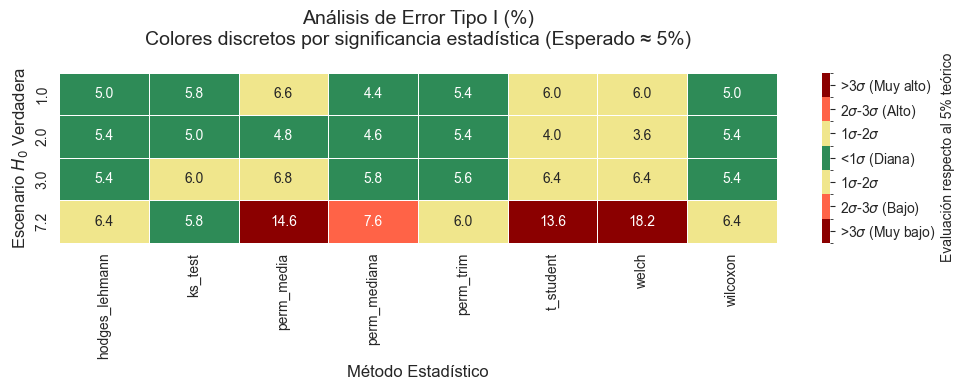

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

tabla_tipo1 = potencia[potencia["escenario"].isin([1, 2, 3, 7.2])].pivot(
    index="escenario", columns="metodo", values="porcentaje"
)

# sigma = sqrt(0.05 * 0.95 / 500)
sigma = np.sqrt(0.05 * 0.95 / 500) * 100  # en porcentaje

mu = 5.0
s1 = sigma
s2 = 2 * sigma
s3 = 3 * sigma

limites = [0, mu - s3, mu - s2, mu - s1, mu + s1, mu + s2, mu + s3, 100]

colores = ['darkred', 'tomato', 'khaki', 'seagreen', 'khaki', 'tomato', 'darkred']
cmap_discreto = ListedColormap(colores)
norm = BoundaryNorm(limites, cmap_discreto.N)

tick_positions = [(limites[i] + limites[i+1]) / 2 for i in range(len(limites)-1)]
tick_labels = [
    r'>3$\sigma$ (Muy bajo)',
    r'2$\sigma$-3$\sigma$ (Bajo)',
    r'1$\sigma$-2$\sigma$',
    r'<1$\sigma$ (Diana)',
    r'1$\sigma$-2$\sigma$',
    r'2$\sigma$-3$\sigma$ (Alto)',
    r'>3$\sigma$ (Muy alto)',
]

plt.figure(figsize=(10, 4))
sns.set_style("white")

ax = sns.heatmap(
    tabla_tipo1,
    annot=True,
    fmt=".1f",
    cmap=cmap_discreto,
    norm=norm,
    cbar_kws={
        "ticks": tick_positions,
        "label": 'Evaluación respecto al 5% teórico'
    },
    linewidths=.5,
    linecolor='white'
)

ax.collections[0].colorbar.set_ticklabels(tick_labels)

plt.title("Análisis de Error Tipo I (%)\nColores discretos por significancia estadística (Esperado ≈ 5%)", fontsize=14, pad=20)
plt.xlabel("Método Estadístico", fontsize=12)
plt.ylabel("Escenario $H_0$ Verdadera", fontsize=12)

plt.tight_layout()
plt.savefig("../resultados/heatmap_error_tipo1.png", dpi=150)
plt.show()

## Potencia

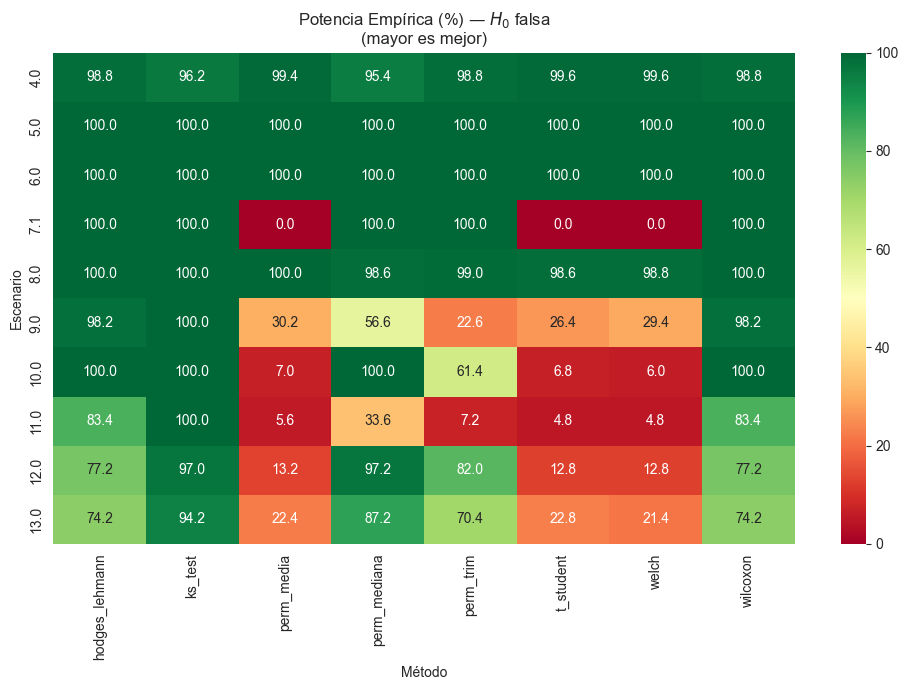

In [16]:
tabla_potencia = potencia[~potencia["escenario"].isin([1, 2, 3, 7, 7.2])].pivot(
    index="escenario", columns="metodo", values="porcentaje"
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    tabla_potencia,
    annot=True, fmt=".1f",
    cmap="RdYlGn",
    vmin=0, vmax=100,
)
plt.title("Potencia Empírica (%) — $H_0$ falsa\n(mayor es mejor)")
plt.xlabel("Método")
plt.ylabel("Escenario")
plt.tight_layout()
plt.savefig("../resultados/heatmap_potencia.png", dpi=150)
plt.show()

## Heatmap de rechazo

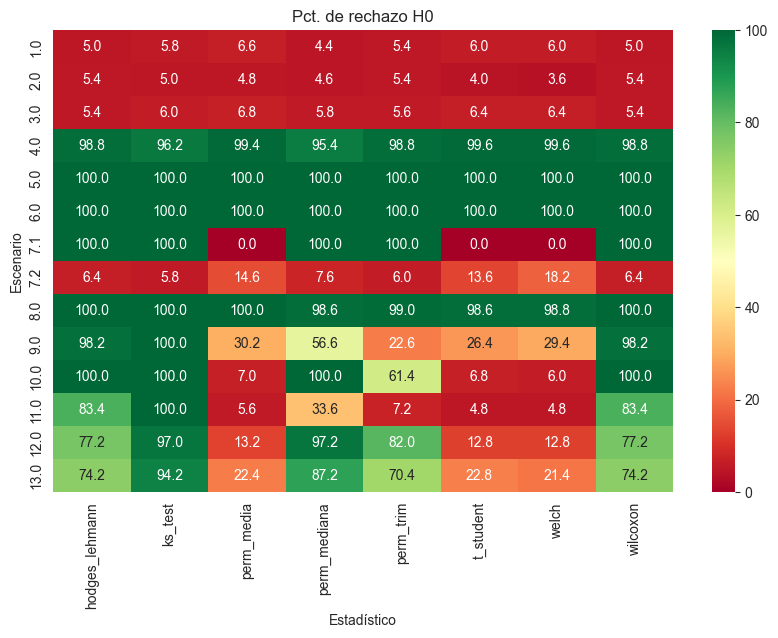

In [17]:
tabla = potencia.pivot(
    index="escenario",
    columns="metodo",
    values="porcentaje"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",   # rojo → amarillo → verde
    vmin=0,
    vmax=100
)

plt.title("Pct. de rechazo H0")
plt.xlabel("Estadístico")
plt.ylabel("Escenario")

plt.show()

## Comparación de Potencia

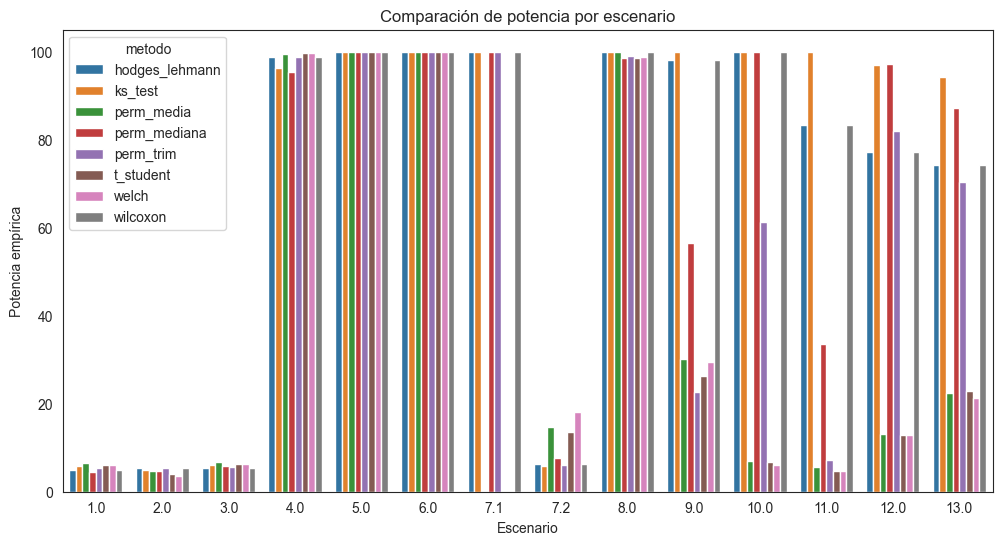

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=potencia,
    x="escenario",
    y="porcentaje",
    hue="metodo"
)

plt.ylabel("Potencia empírica")
plt.xlabel("Escenario")
plt.title("Comparación de potencia por escenario")

plt.show()

In [19]:
df["metodo"].unique()

<StringArray>
[     't_student',          'welch',       'wilcoxon',        'ks_test',
 'hodges_lehmann',     'perm_media',   'perm_mediana',      'perm_trim']
Length: 8, dtype: str

# Tiempo de Ejecución

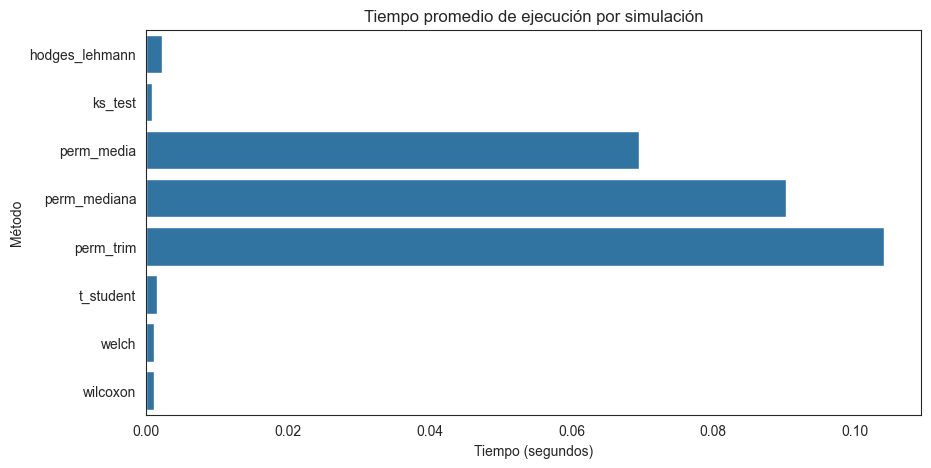

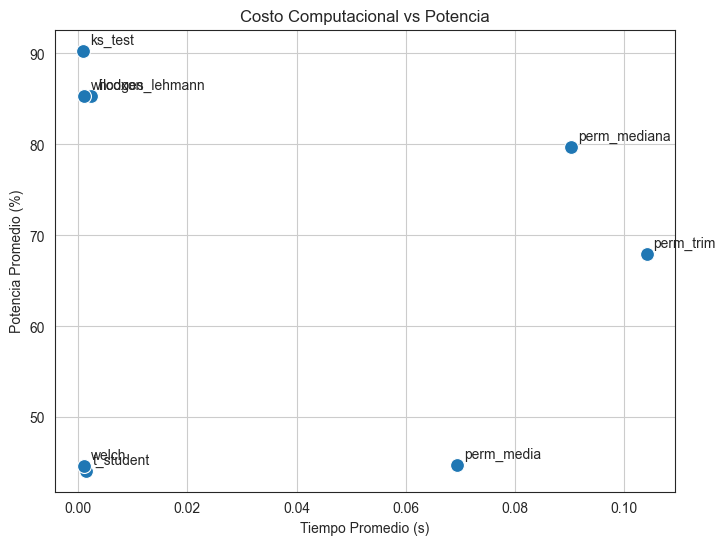

In [20]:
# Gráfico de barras de tiempo de ejecución
tiempos = df.groupby('metodo')['tiempo'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=tiempos, x='tiempo', y='metodo', orient='h')
plt.title('Tiempo promedio de ejecución por simulación')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Método')
plt.show()

# Gráfico Costo-Beneficio (Potencia excluyendo casos nulos 1, 2, 3 vs Tiempo)
potencia_real = df[~df['escenario'].isin([1, 2, 3])].groupby('metodo')['resultado'].mean() * 100
resumen = pd.DataFrame({
    'Potencia Promedio (%)': potencia_real,
    'Tiempo Promedio (s)': tiempos.set_index('metodo')['tiempo']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=resumen, x='Tiempo Promedio (s)', y='Potencia Promedio (%)', s=100)

for i, txt in enumerate(resumen.index):
    plt.annotate(txt, (resumen['Tiempo Promedio (s)'].iloc[i], resumen['Potencia Promedio (%)'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points')

plt.title('Costo Computacional vs Potencia')
plt.grid(True)
plt.show()